In [70]:
import pandas as pd
from pandas.api.types import CategoricalDtype

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from scipy import sparse

In [56]:
train = pd.read_csv("data/train.csv", index_col = "id")
test = pd.read_csv("data/test.csv", index_col = "id")
submission = pd.read_csv("data/sample_submission.csv", index_col = "id")

# 1. Exploratory Data Analysis

In [90]:
def resumtable(df):
    print(f"data shape: {df.shape}")
    summary = pd.DataFrame(df.dtypes, columns = ['data type'])
    summary = summary.reset_index()
    summary = summary.rename(columns = {"index": "feature"})
    summary["num_NULL"] = df.isnull().sum().values
    summary["num_UNI"] = df.nunique().values
    summary["first_val"] = df.loc[0].values
    summary["second_val"] = df.loc[1].values
    summary["third_val"] = df.loc[2].values
    
    return summary

In [91]:
resumtable(train)

data shape: (300000, 24)


,feature,data type,num_NULL,num_UNI,first_val,second_val,third_val
0,bin_0,int64,0,2,0,0,0
1,bin_1,int64,0,2,0,1,0
2,bin_2,int64,0,2,0,0,0
3,bin_3,object,0,2,T,T,F
4,bin_4,object,0,2,Y,Y,Y
5,nom_0,object,0,3,Green,Green,Blue
6,nom_1,object,0,6,Triangle,Trapezoid,Trapezoid
7,nom_2,object,0,6,Snake,Hamster,Lion
8,nom_3,object,0,6,Finland,Russia,Russia
9,nom_4,object,0,4,Bassoon,Piano,Theremin


1. binary feature: bin_0 ~ bin_4
2. nominal feature: nom_0 ~ nom_9
3. ordinal feature: ord_0 ~ ord_5
4. others: day, month, target

binary feature:
- No Null data
- 2 unique values (because these are binary features)
- Need to change T, F, Y, N object types to int types (need dummy encoding)

Nominal feature:
- No Null data
- From nom_0 to nom_4 have at most 6 unique values, but from nom_5 to nom_9 have a lot of unique values
- Also, from nom_5 to nom_9 represent Uninterpretable values

Ordianl feature: 
- No Null data
- Except for ord_0, all the features are object types
- To recognize the order of these features, we need to print out their unique values (Because the impact on the target value differs depending on the order)

In [92]:
for i in range(3):
    feature = "ord_" + str(i)
    print(f"{feature}'s unique value: {train[feature].unique()}")

ord_0's unique value: [2 1 3]
ord_1's unique value: ['Grandmaster' 'Expert' 'Novice' 'Contributor' 'Master']
ord_2's unique value: ['Cold' 'Hot' 'Lava Hot' 'Boiling Hot' 'Freezing' 'Warm']


- The unique values of the ord_0 feature are all plain numbers, so we need to arrange them in the numerical order
- The ord_1 feature represents kaggle's ranking tiers (Novice, Contributor, Expert, Master, Grandmaster)
- The ord_2 feature represents levels of temperature, indicating how hot or cold something is

In [93]:
for i in range(3, 6):
    feature = "ord_" + str(i)
    print(f"{feature}'s unique value: {train[feature].unique()}")

ord_3's unique value: ['h' 'a' 'i' 'j' 'g' 'e' 'd' 'b' 'k' 'f' 'l' 'n' 'o' 'c' 'm']
ord_4's unique value: ['D' 'A' 'R' 'E' 'P' 'K' 'V' 'Q' 'Z' 'L' 'F' 'T' 'U' 'S' 'Y' 'B' 'H' 'J'
 'N' 'G' 'W' 'I' 'O' 'C' 'X' 'M']
ord_5's unique value: ['kr' 'bF' 'Jc' 'kW' 'qP' 'PZ' 'wy' 'Ed' 'qo' 'CZ' 'qX' 'su' 'dP' 'aP'
 'MV' 'oC' 'RL' 'fh' 'gJ' 'Hj' 'TR' 'CL' 'Sc' 'eQ' 'kC' 'qK' 'dh' 'gM'
 'Jf' 'fO' 'Eg' 'KZ' 'Vx' 'Fo' 'sV' 'eb' 'YC' 'RG' 'Ye' 'qA' 'lL' 'Qh'
 'Bd' 'be' 'hT' 'lF' 'nX' 'kK' 'av' 'uS' 'Jt' 'PA' 'Er' 'Qb' 'od' 'ut'
 'Dx' 'Xi' 'on' 'Dc' 'sD' 'rZ' 'Uu' 'sn' 'yc' 'Gb' 'Kq' 'dQ' 'hp' 'kL'
 'je' 'CU' 'Fd' 'PQ' 'Bn' 'ex' 'hh' 'ac' 'rp' 'dE' 'oG' 'oK' 'cp' 'mm'
 'vK' 'ek' 'dO' 'XI' 'CM' 'Vf' 'aO' 'qv' 'jp' 'Zq' 'Qo' 'DN' 'TZ' 'ke'
 'cG' 'tP' 'ud' 'tv' 'aM' 'xy' 'lx' 'To' 'uy' 'ZS' 'vy' 'ZR' 'AP' 'GJ'
 'Wv' 'ri' 'qw' 'Xh' 'FI' 'nh' 'KR' 'dB' 'BE' 'Bb' 'mc' 'MC' 'tM' 'NV'
 'ih' 'IK' 'Ob' 'RP' 'dN' 'us' 'dZ' 'yN' 'Nf' 'QM' 'jV' 'sY' 'wu' 'SB'
 'UO' 'Mx' 'JX' 'Ry' 'Uk' 'uJ' 'LE' 'ps' 'kE' 'MO' 'kw'

- The ord_3, ord_4, and ord_5 features are in alphabetical order
- I will encode them in alphabetical order later

In [94]:
print("day's unique val", train['day'].unique())
print("month's uniuqe val", train['month'].unique())
print("target's unique val", train['target'].unique())

day's unique val [2 7 5 4 3 1 6]
month's uniuqe val [ 2  8  1  4 10  3  7  9 12 11  5  6]
target's unique val [0 1]


- The day feature has 7 unique values, which seem to represent each day of the week (from Monday to Sunday).
- The month feature has 12 unique values, which seem to represent each month (from January to December).
- The target feature has two unique values.

### 1.1 Data visualization

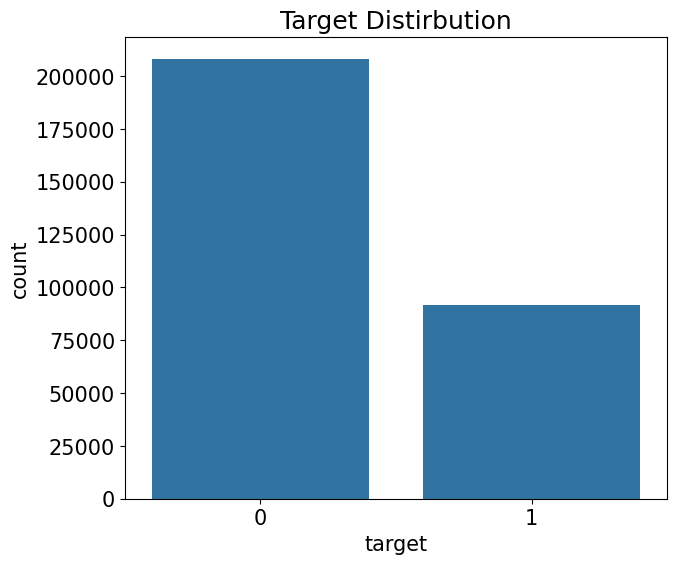

In [95]:
mpl.rc("font", size = 15)
plt.figure(figsize = (7, 6))

ax = sns.countplot(x = "target", data = train)
ax.set_title("Target Distirbution");

In [96]:
rectangle = ax.patches[0]
print("rec height:", rectangle.get_height())
print("rec width:", rectangle.get_width())
print("rec left coord:", rectangle.get_x())

rec height: 208236.0
rec width: 0.8
rec left coord: -0.4


In [97]:
print("text x axis:", rectangle.get_x() + rectangle.get_width() / 2.0)
print("text y axis:", rectangle.get_height() + len(train) * 0.001)

text x axis: 0.0
text y axis: 208536.0


In [98]:
def write_percent(ax, total_size):
    """Iterates over shape objects and 
    displays the target value ratio at the top of each bar"""
    for patch in ax.patches:
        height = patch.get_height()
        width = patch.get_width()
        left_coord = patch.get_x()
        percent = height/total_size * 100

        ax.text(x = left_coord + width/2.0,
                y = height + total_size * 0.001,
                s = f"{percent: 1.1f}%",
                ha = "center")

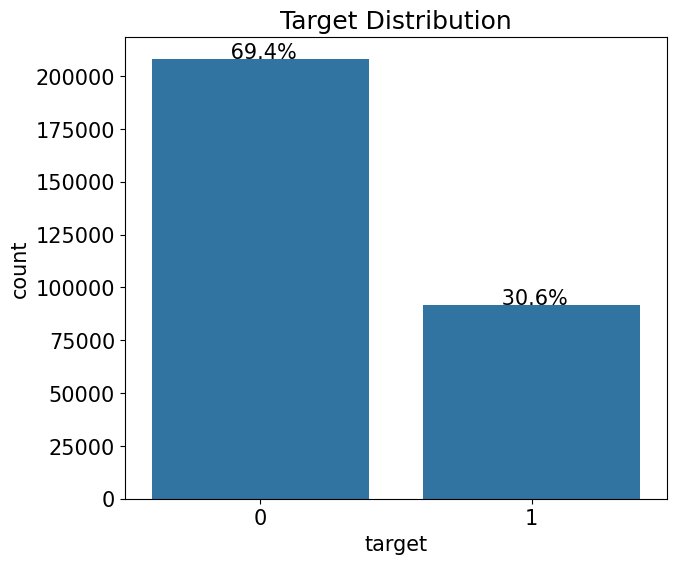

In [99]:
plt.figure(figsize = (7, 6))

ax = sns.countplot(x = "target", data = train)
write_percent(ax, len(train))
ax.set_title("Target Distribution");

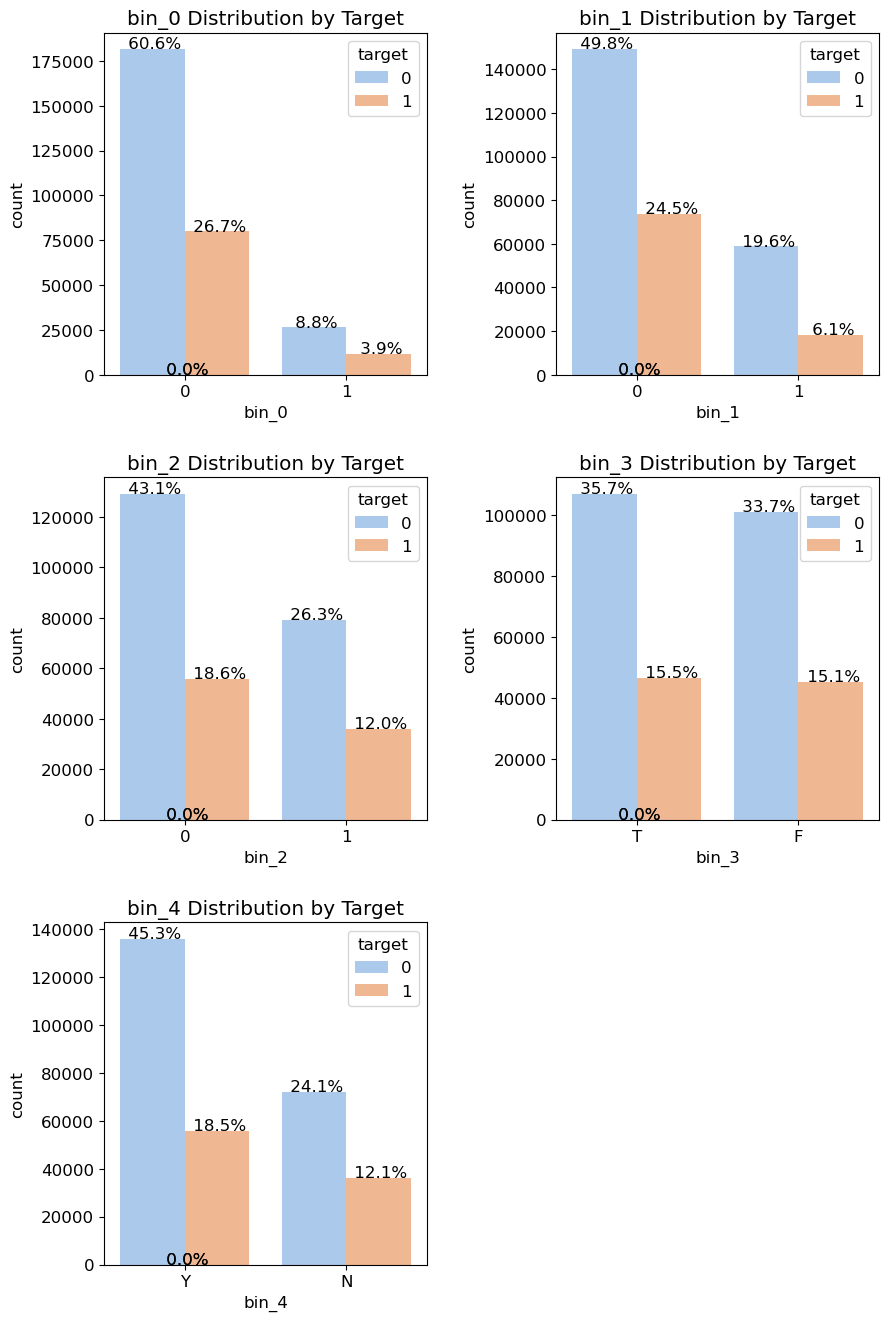

In [100]:
# Binary feature distribution

mpl.rc("font", size = 12)
grid = gridspec.GridSpec(3, 2) # 3 x 2
plt.figure(figsize = (10, 16))
plt.subplots_adjust(wspace = 0.4, hspace = 0.3)

bin_features = ["bin_0", "bin_1", "bin_2", "bin_3", "bin_4"]

for idx, feature in enumerate(bin_features):
    ax = plt.subplot(grid[idx])

    sns.countplot(x = feature, data = train, hue = "target", palette = "pastel", ax = ax)
    ax.set_title(f"{feature} Distribution by Target")
    write_percent(ax, len(train))

In [101]:
# nominal feature distribution
def get_crosstab(df, feature):
    crosstab = pd.crosstab(df[feature], df["target"], normalize = "index") * 100
    crosstab = crosstab.reset_index()
    return crosstab

In [102]:
crosstab = get_crosstab(train, "nom_0")
crosstab

target,nom_0,0,1
0,Blue,75.820976,24.179024
1,Green,67.285478,32.714522
2,Red,64.894827,35.105173


In [103]:
def plot_pointplot(ax, feature, crosstab):
    ax2 = ax.twinx()
    ax2 = sns.pointplot(x = feature, y = 1, data = crosstab,
                        order = crosstab[feature].values, color = "black", legend = False)
    ax2.set_ylim(crosstab[1].min() - 5, crosstab[1].max() * 1.1)
    ax2.set_ylabel("Target 1 Ratio (%)")

In [104]:
def plot_cat_dist_with_true_ratio(df, features, num_rows, num_cols, size = (15, 20)):
    plt.figure(figsize = size)
    grid = gridspec.GridSpec(num_rows, num_cols)
    plt.subplots_adjust(wspace = 0.45, hspace = 0.3)

    for idx, feature in enumerate(features):
        ax = plt.subplot(grid[idx])
        crosstab = get_crosstab(df, feature)

        sns.countplot(x = feature, data = df,
                      order = crosstab[feature].values, color = 'skyblue', ax = ax)
        write_percent(ax, len(df))
        plot_pointplot(ax, feature, crosstab)
        ax.set_title(f"{feature} Distribution")

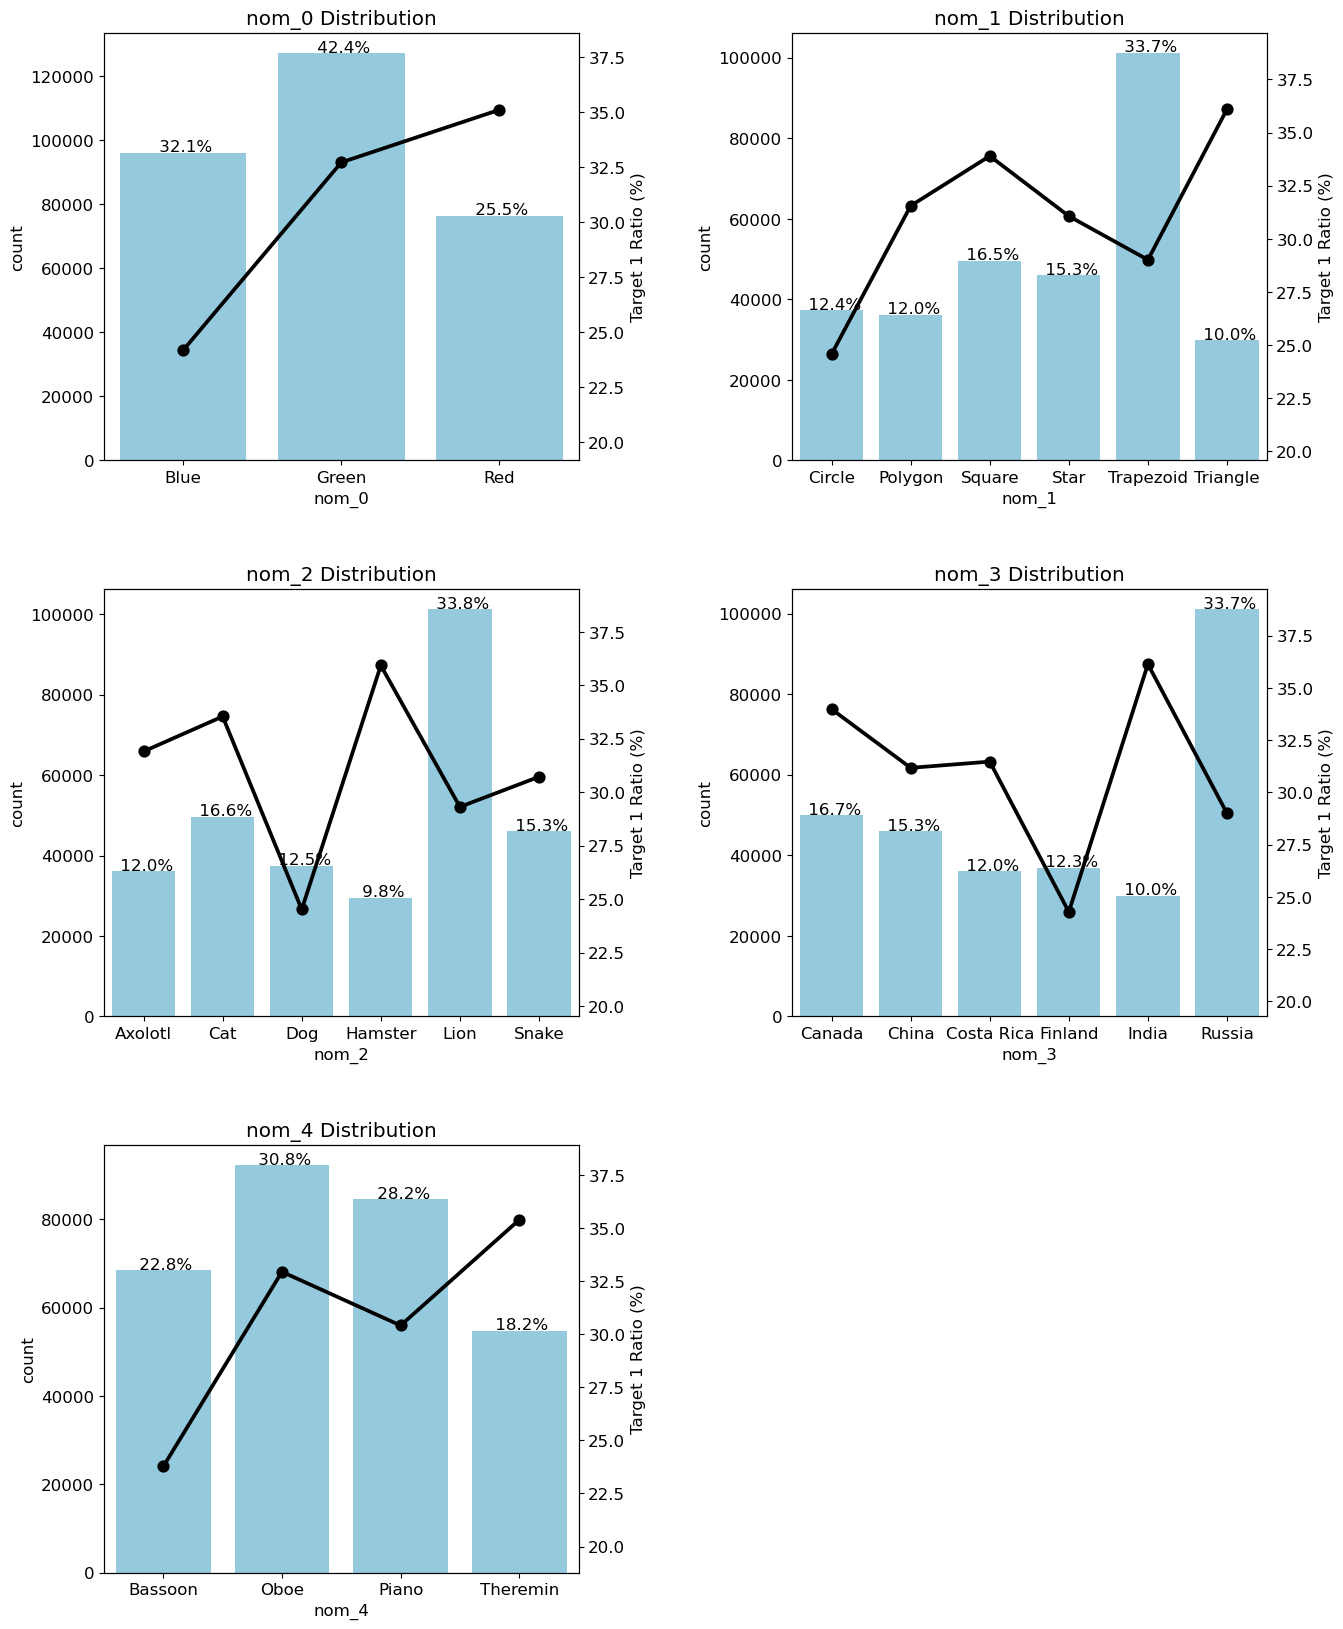

In [105]:
nom_features = ["nom_0", "nom_1", "nom_2", "nom_3", "nom_4"]
plot_cat_dist_with_true_ratio(train, nom_features, num_rows = 3, num_cols = 2)

- These five nominal features have different target value 1 ratios for each unique value. This indicates that they have predictive power for the target variable. Therefore, none of the features from `nom_0` to `nom_4` are unnecessary for modeling. All of them should be used in the model.
- The features from `nom_5` to `nom_9` have an excessively large number of unique values and are composed of meaningless characters, making them difficult to visualize. Therefore, these features are assumed to be necessary for modeling and will be included in the process. One-hot encoding will be applied to these features later.

In [106]:
# ordinal feature distribution

ord_1_value = ['Novice', 'Contributor', 'Expert', 'Master', 'Grandmaster']
ord_2_value = ['Freezing', 'Cold', 'Warm', 'Hot', 'Boiling Hot', 'Lava Hot']

ord_1_dtype = CategoricalDtype(categories = ord_1_value, ordered = True)
ord_2_dtype = CategoricalDtype(categories = ord_2_value, ordered = True)

train['ord_1']= train['ord_1'].astype(ord_1_dtype)
train['ord_2']= train['ord_2'].astype(ord_2_dtype)

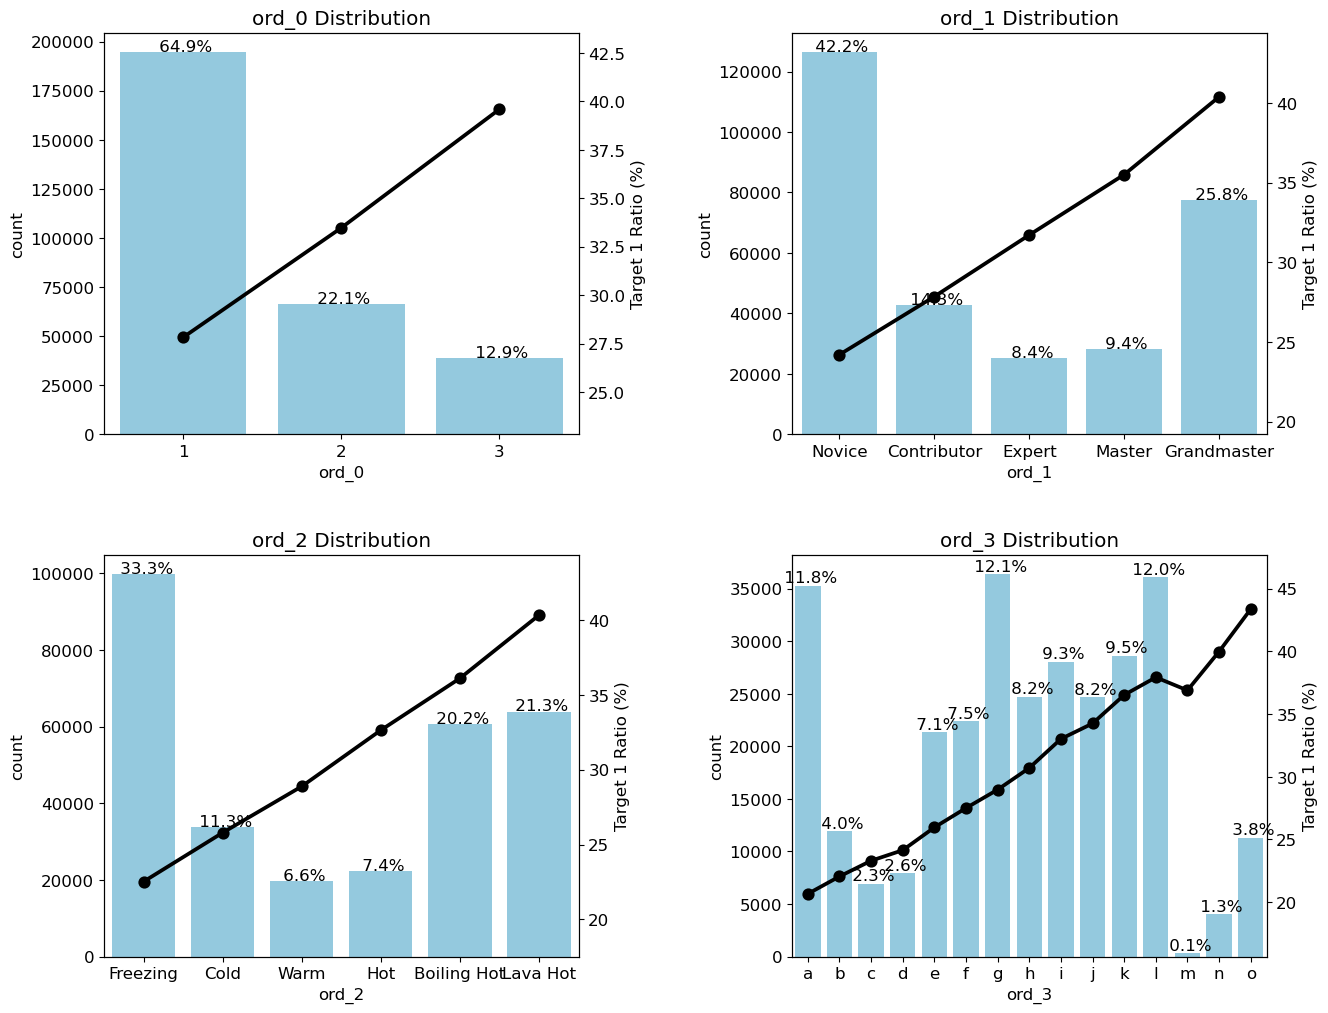

In [107]:
ord_features = ["ord_0", "ord_1", "ord_2", "ord_3"] 
plot_cat_dist_with_true_ratio(train, ord_features, num_rows = 2, num_cols = 2, size = (15, 12))

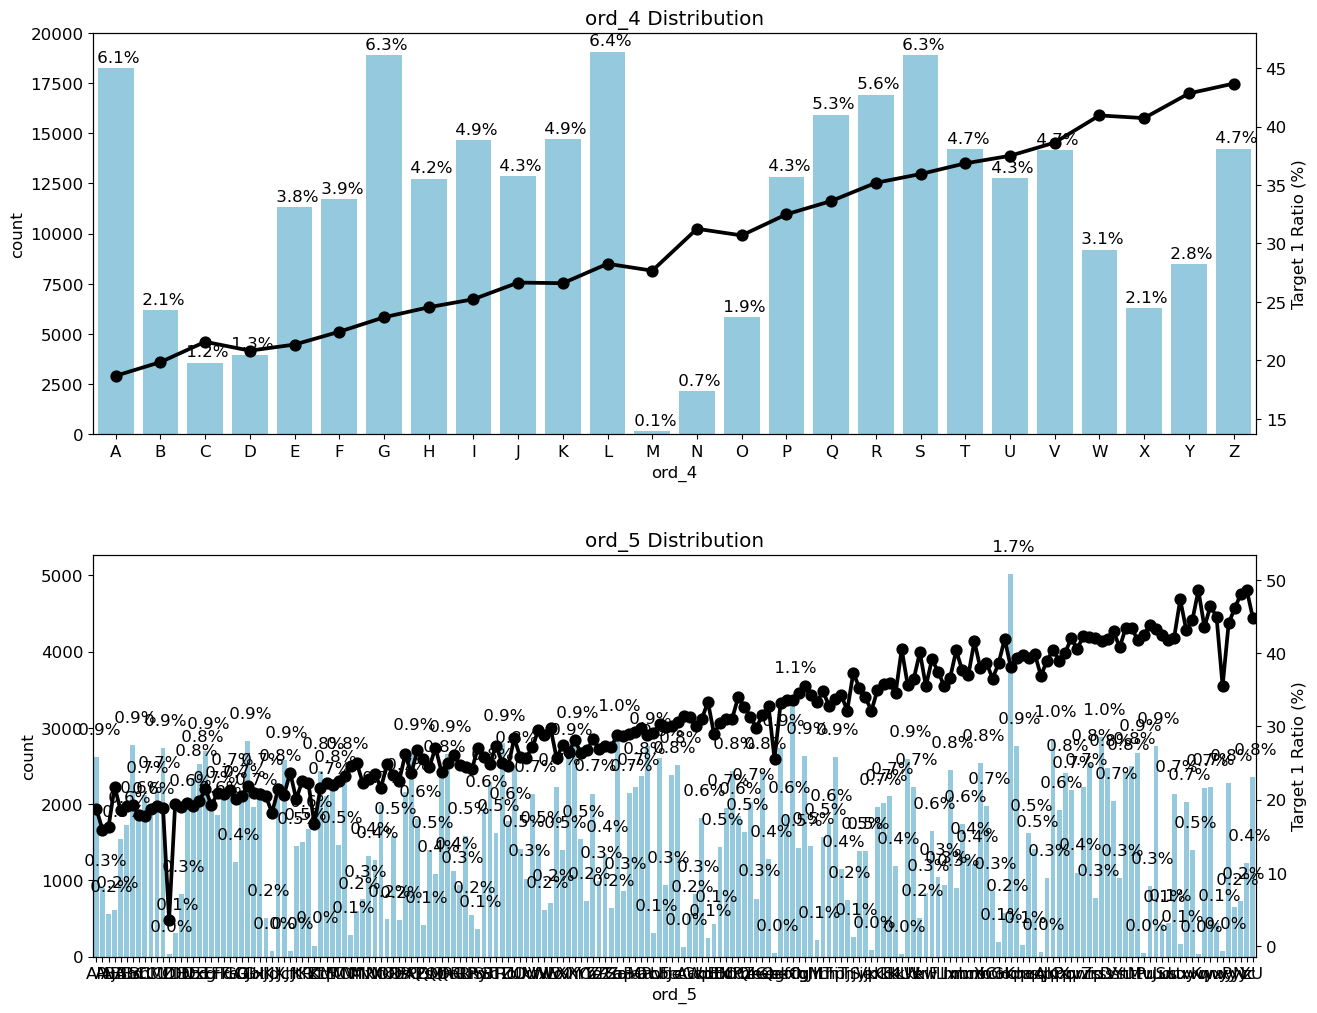

In [108]:
plot_cat_dist_with_true_ratio(train, ["ord_4", "ord_5"],
                              num_rows = 2, num_cols = 1, size = (15, 12))

- The ord_5 feature has so many unique values that the x-axis labels overlap. However, this does not affect the ability to observe the overall trend in the ratio of target value 1.
- It is clear that for all ordinal features, the proportion of target value 1 increases according to the order of the unique values.

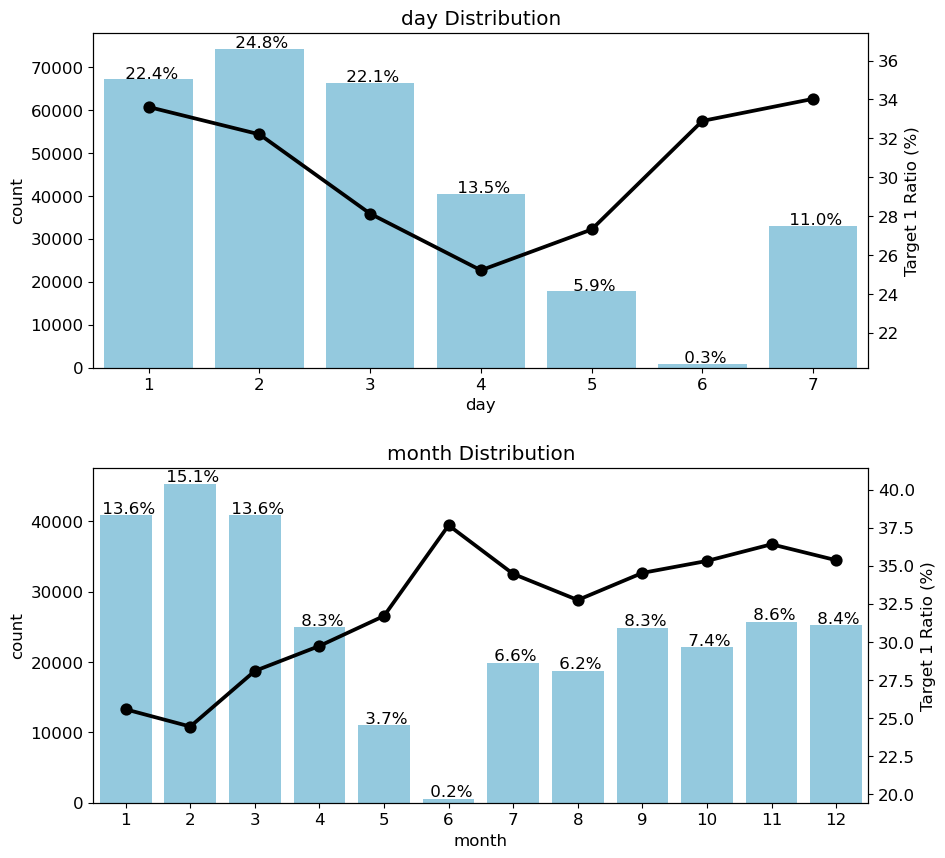

In [110]:
# date feature distribution

date_features = ['day', 'month']
plot_cat_dist_with_true_ratio(train, date_features, num_rows = 2, num_cols = 1, size = (10, 10))

- The day and month features are cyclical data. Since machine learning models interpret numerical differences with varying weights, these features need to be encoded using either trigonometric encoding (sine and cosine) or one-hot encoding.

#### EDA Evaluation
- No missing values.
- All features are important, so none will be removed.
- Binary feature encoding: Binary features with non-numeric values will be encoded as 0 and 1.
- Nominal feature encoding: Since the dataset is not large, all nominal features will be encoded using one-hot encoding.
- Ordinal feature encoding: Ordinal features will be encoded according to the order of their unique values.
- Date feature encoding: To avoid interpreting the values as magnitudes, date features will be encoded using one-hot encoding.

# 2. Baseline Model

### 2.1 Feature Engineering

In [3]:
all_data = pd.concat([train, test])
all_data = all_data.drop("target", axis = 1)

In [4]:
encoder = OneHotEncoder()
all_data_encoded = encoder.fit_transform(all_data)

In [5]:
num_train = len(train)
X_train = all_data_encoded[:num_train]
X_test = all_data_encoded[num_train:]
y = train['target']

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y, test_size = 0.1, stratify = y)

### 2.2 Train the model

In [7]:
glm = LogisticRegression(max_iter = 1000, random_state = 42)
glm.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### 2.3 Evaluate the model

In [8]:
glm.predict_proba(X_valid)

array([[0.80585553, 0.19414447],
       [0.10324191, 0.89675809],
       [0.69094055, 0.30905945],
       ...,
       [0.95431086, 0.04568914],
       [0.82202005, 0.17797995],
       [0.37591445, 0.62408555]])

In [9]:
glm.predict(X_valid)

array([0, 1, 0, ..., 0, 0, 1])

In [10]:
y_valid_preds = glm.predict_proba(X_valid)[:, 1]

In [11]:
roc_auc = roc_auc_score(y_valid, y_valid_preds)
print(f"Valid data's ROC AUC: {roc_auc:.4f}")

Valid data's ROC AUC: 0.7997


In [12]:
y_preds = glm.predict_proba(X_test)[:, 1]

### 2.4 First submssion

In [134]:
submission['target'] = y_preds
submission.to_csv("submission.csv")

# 3. Model Optimization

To enhance performance, the model will be optimized with a focus on the following three aspects:
1. Feature-specific Encoding: Apply encoding methods tailored to the characteristics of each feature.
2. Feature Scaling: Ensure proper scaling of features to improve model training and convergence.
3. Hyperparameter Optimization: Fine-tune model hyperparameters to achieve optimal performance.

### 3.1 Feature-specific encoding

In [57]:
all_data = pd.concat([train, test])
all_data = all_data.drop("target", axis = 1)

In [58]:
# Binary feature encoding

all_data["bin_3"] = all_data["bin_3"].map({'F': 0, 'T': 1})
all_data["bin_4"] = all_data["bin_4"].map({'N': 0, 'Y': 1})

In [59]:
# Ordinary feature encoding

ord1dict = {'Novice': 0, 
            'Contributor': 1,
            'Expert': 2,
            'Master': 3,
            'Grandmaster': 4}

ord2dict = {'Freezing': 0,
            'Cold': 1,
            'Warm': 2,
            'Hot': 3,
            'Boiling Hot': 4,
            'Lava Hot': 5}

all_data["ord_1"] = all_data["ord_1"].map(ord1dict)
all_data["ord_2"] = all_data["ord_2"].map(ord2dict)

In [60]:
ord_345 = ['ord_3', 'ord_4', 'ord_5']

ord_encoder = OrdinalEncoder()

all_data[ord_345] = ord_encoder.fit_transform(all_data[ord_345])

# for feature, categories in zip(ord_345, ord_encoder.categories_):
#     print(feature)
#     print(categories)

In [61]:
# nominal feature encoding

nom_features = ['nom_' + str(i) for i in range(10)]
onehot_encoder = OneHotEncoder()

encoded_nom_matrix = onehot_encoder.fit_transform(all_data[nom_features])

all_data = all_data.drop(nom_features, axis = 1)

In [62]:
# Date feature encoding

date_features = ['day', 'month']

encoded_date_matrix = onehot_encoder.fit_transform(all_data[date_features])

all_data = all_data.drop(date_features, axis = 1)

### 3.2 Feature scaling

In [63]:
# MinMax scaling for ordinal features

ord_features = ['ord_' + str(i) for i in range(6)]

all_data[ord_features] = MinMaxScaler().fit_transform(all_data[ord_features])

In [66]:
# merging all the encoded features (csr format)

all_data_sprs = sparse.hstack([sparse.csr_matrix(all_data),
                               encoded_nom_matrix, 
                               encoded_date_matrix], format = 'csr')

In [67]:
all_data_sprs

<500000x16306 sparse matrix of type '<class 'numpy.float64'>'
	with 9163718 stored elements in Compressed Sparse Row format>

### 3.3 Hyperparameter Tuning (GridSearch CV)

In [68]:
num_train = len(train)

X_train = all_data_sprs[:num_train]
X_test = all_data_sprs[num_train:]
y = train['target']

In [69]:
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y, test_size = 0.1, stratify = y)

In [71]:
glm = LogisticRegression()

In [72]:
glm_params = {"C": [0.1, 0.125, 0.2],
              "max_iter": [800, 900, 1000],
              "solver": ["liblinear"],
              "random_state": [42]}

In [74]:
gridsearch_glm = GridSearchCV(estimator = glm,
                              param_grid = glm_params,
                              scoring = "roc_auc",
                              cv = 5)

gridsearch_glm.fit(X_train, y_train)

print("optimal parameter:", gridsearch_glm.best_params_)

optimal parameter: {'C': 0.125, 'max_iter': 800, 'random_state': 42, 'solver': 'liblinear'}


In [75]:
y_valid_preds = gridsearch_glm.predict_proba(X_valid)[:, 1]

In [78]:
roc_auc = roc_auc_score(y_valid, y_valid_preds)
print(f"Valid data's ROC AUC score: {roc_auc:.4f}")

Valid data's ROC AUC score: 0.8021


# 4. Second Submssion

In [80]:
y_preds = gridsearch_glm.best_estimator_.predict_proba(X_test)[:, 1]

submission['target'] = y_preds
submission.to_csv('submission.csv')